# 04: Backtest Evaluation
**Goal:** Turn the weight decisions from Notebook 03 into an actual portfolio value
simulation, and compare equal-weight, Markowitz, and mean-CVaR on Sharpe, Sortino,
Maximum Drawdown, CVaR, and turnover.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROCESSED = Path("../data/processed")

returns = pd.read_csv(PROCESSED / "log_returns.csv", index_col=0, parse_dates=True)
weights_long = pd.read_csv(PROCESSED / "portfolio_weights.csv", parse_dates=["date"])
tickers = returns.columns.tolist()
methods = weights_long["method"].unique().tolist()

rebalance_dates = sorted(weights_long["date"].unique())
print("methods:", methods)
print("rebalance dates:", len(rebalance_dates), "-", rebalance_dates[0], "to", rebalance_dates[-1])

methods: ['equal_weight', 'markowitz', 'cvar']
rebalance dates: 21 - 2024-11-19 00:00:00 to 2026-07-28 00:00:00


## Simulating portfolio value

For each day, use the weights from the most recent rebalance date and apply that day's
simple (non-log) returns. Simple returns are used here rather than log returns because a
portfolio's value is a weighted sum of simple asset returns, not log returns.

In [2]:
simple_returns = np.expm1(returns)

test_start = rebalance_dates[0]
test_end = returns.index.max()
sim_dates = returns.index[(returns.index >= test_start) & (returns.index <= test_end)]

def current_weights_for_date(day, method_weights_by_date, rebalance_dates):
    applicable = [d for d in rebalance_dates if d <= day]
    if not applicable:
        return None
    return method_weights_by_date.get(max(applicable))

results = {}
for method in methods:
    sub = weights_long[weights_long["method"] == method].set_index("date")
    method_weights_by_date = {d: sub.loc[d, tickers] for d in sub.index}
    port_returns = []
    for day in sim_dates:
        w = current_weights_for_date(day, method_weights_by_date, rebalance_dates)
        day_ret = simple_returns.loc[day, tickers]
        port_returns.append(float((w.values * day_ret.values).sum()) if w is not None else np.nan)
    results[method] = pd.Series(port_returns, index=sim_dates, name=method).dropna()

port_ret_df = pd.DataFrame(results)
port_ret_df.shape

(438, 3)

## Metrics
$$
\text{Sharpe} = \frac{\mu_p - r_f}{\sigma_p}, \qquad
\text{Sortino} = \frac{\mu_p - r_f}{\sigma_{\text{downside}}}, \qquad
\text{MDD} = \min_t \frac{V_t - \max_{s \le t} V_s}{\max_{s \le t} V_s}, \qquad
\text{Calmar} = \frac{\mu_p}{|\text{MDD}|}
$$

In [3]:
def max_drawdown(cum_value):
    running_max = cum_value.cummax()
    return ((cum_value - running_max) / running_max).min()

def compute_metrics(daily_returns, rf=0.0):
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - rf) / ann_vol if ann_vol > 0 else np.nan
    downside = daily_returns[daily_returns < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) > 1 else np.nan
    sortino = (ann_return - rf) / downside_vol if downside_vol and downside_vol > 0 else np.nan
    cum_value = (1 + daily_returns).cumprod()
    mdd = max_drawdown(cum_value)
    calmar = ann_return / abs(mdd) if mdd < 0 else np.nan
    return {
        "ann_return": ann_return, "ann_vol": ann_vol, "sharpe": sharpe, "sortino": sortino,
        "calmar": calmar,
        "max_drawdown": mdd,
        "cvar_95_daily": daily_returns[daily_returns <= daily_returns.quantile(0.05)].mean(),
    }

metrics_df = pd.DataFrame({m: compute_metrics(port_ret_df[m]) for m in methods}).T
metrics_df.round(4)

,ann_return,ann_vol,sharpe,sortino,calmar,max_drawdown,cvar_95_daily
equal_weight,0.1605,0.1035,1.5501,2.0118,1.5798,-0.1016,-0.0153
markowitz,0.1999,0.0968,2.0650,2.6941,3.1840,-0.0628,-0.0144
cvar,0.0817,0.0547,1.4920,1.8891,1.6934,-0.0482,-0.0084


## Turnover

In [4]:
def compute_turnover(method):
    sub = weights_long[weights_long["method"] == method].sort_values("date").set_index("date")[tickers]
    return sub.diff().abs().sum(axis=1).mean()

turnover = pd.Series({m: compute_turnover(m) for m in methods}, name="avg_turnover_per_rebalance")
turnover.round(4)

equal_weight    0.0000
markowitz       0.5719
cvar            0.0825
Name: avg_turnover_per_rebalance, dtype: float64

## Cumulative performance

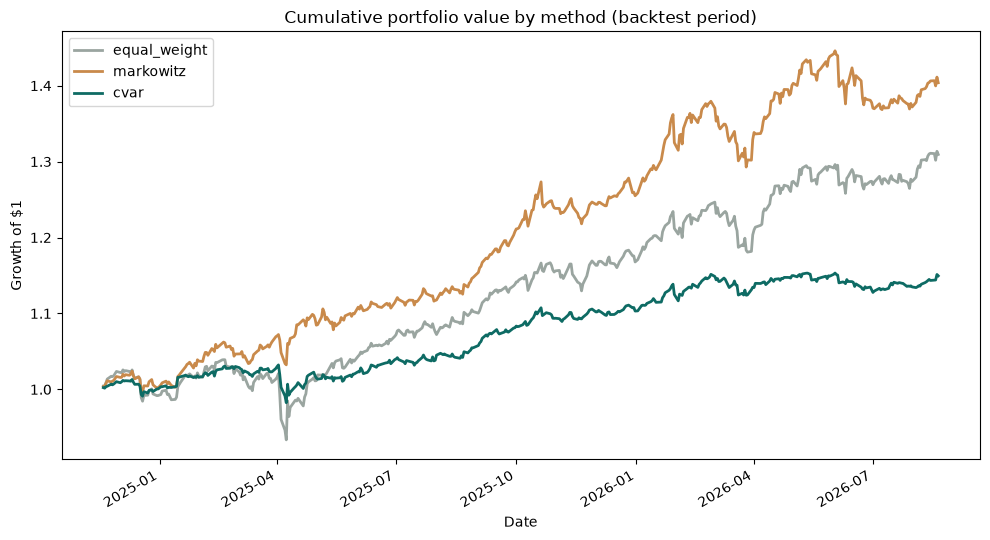

equal_weight    1.3094
markowitz       1.4038
cvar            1.1495
Name: 2026-08-20 00:00:00, dtype: float64

In [5]:
cum_values = (1 + port_ret_df).cumprod()

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = {"equal_weight": "#9aa5a0", "markowitz": "#c98a4b", "cvar": "#0e6b64"}
for m in methods:
    cum_values[m].plot(ax=ax, label=m, color=colors.get(m), linewidth=2)
ax.set_title("Cumulative portfolio value by method (backtest period)")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()

cum_values.iloc[-1].round(4)

## Reading the result

In [6]:
metrics_df["avg_turnover_per_rebalance"] = turnover
metrics_df.to_csv(PROCESSED / "backtest_metrics.csv")
port_ret_df.to_csv(PROCESSED / "backtest_daily_returns.csv")
print("Saved: backtest_metrics.csv, backtest_daily_returns.csv")

Saved: backtest_metrics.csv, backtest_daily_returns.csv
